## 1. Purpose

Notebook for the two gradient-descent models: DNN and PINN, no-environment feature
set. The baselines (sklearn + Chapman-Richards) have their own notebook
(`baseline_results.ipynb`) — they don't use gradient descent, so they have no loss
curves to plot here.

This notebook only reads what's already saved under `outputs/`. It never trains or
evaluates anything itself. See section 2 for which scripts to run first.

Covers both split types:
- `temporal` — train on the earliest years, validate on 2021, test on 2023
- `spatial_block` — train/val/test are whole held-out forestry compartments

What this notebook does:
1. Plots training/validation loss curves for whatever runs exist, plus learning-rate,
   gradient-norm, and generalization-gap diagnostics (section 3).
2. Shows a results table comparing DNN/PINN to the baselines, matched by split type.
3. Keeps a full, current record of every experiment tried (section 5).
4. Documents both physics/trajectory-weight sweeps (`spatial_block` and `temporal`),
   with every swept config's loss curve overlaid on one graph per cohort/split
   (sections 8-9), plus a multi-seed variance check once that data exists (section 10).

**Known limitation, honest about it rather than hidden**: every result in this
notebook (weight sweeps included) is a SINGLE random seed per configuration. Section
10 documents a reseed check now in progress specifically to test whether the
close-margin comparisons here (some sweep values a fraction of a percent apart,
DNN-vs-PINN in some cohorts under 1% apart) are real signal or single-seed noise —
see `documentation/experiment_log.md` for the up-to-date result once it lands.


**Current state (2026-07-20)**: `pw=tw=0.05` kept as PINN's shared default after a multi-seed
reseed check — but only 4survey's `W=0.0` preference is confirmed robust (6/6 seed×split checks,
section 8.1/9.1); 6survey's exact optimum is unresolvable given seed noise, not a settled number.
DNN robustly wins 4survey; DNN and PINN are tied within noise on 6survey (section 10) — not "PINN
wins 6survey" as originally reported. `temporal_narrow_gap` confirms gap length, not general
temporal difficulty, drives `temporal_wide_gap`'s degradation (section 11). See section 6.1 for
what this means going forward (Env-PINN).

**Contents**
- [1. Purpose](#1-purpose)
- [2. Which files to run](#2-which-files-to-run-to-recompile-these-results)
- [3. Training / validation loss curves](#3-training-validation-loss-curves)
- [4. Test-set metrics: DNN/PINN vs. baselines](#4-test-set-metrics-dnnpinn-vs-the-matching-split-type-baselines)
- [5. Experiments run so far](#5-experiments-run-so-far-dnnpinn-specifically)
- [6. Ideas for parameter tuning / 6.1 Lessons for Env-PINN](#6-ideas-for-parameter-tuning)
- [7. Tuning result, before vs after](#7-tuning-result-both-split-types-before-vs-after)
- [8. Physics-weight sweep — spatial_block / 8.1 reseed check](#8-pinn-physics_weighttrajectory_weight-sweep-spatial_block)
- [9. Physics-weight sweep — temporal / 9.1 reseed check](#9-pinn-physics_weighttrajectory_weight-sweep-temporal-2026-07-18)
- [10. DNN vs. PINN: does the margin survive a different seed?](#10-dnn-vs-pinn-does-the-accuracy-margin-survive-a-different-seed-2026-07-20)
- [11. `temporal_narrow_gap`](#11-temporal_narrow_gap-is-the-11-year-gap-itself-the-problem-2026-07-20)

In [1]:
# Purpose: Make the models/ package importable from this notebook.
# Key logic: Walk upward from the current folder until a folder containing
# both README.md and data/ is found — that is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from models.common.plotting import (
    plot_generalization_gap,
    plot_gradient_norm_curve,
    plot_learning_rate_curve,
    plot_loss_curve,
    plot_loss_curve_comparison,
)
from models.common.saving import model_output_dir

pd.set_option("display.max_columns", 50)

COHORTS = ["4survey", "6survey"]
NEURAL_MODELS = ["dnn_noenv", "pinn_noenv"]
BASELINE_MODELS = ["chapman_richards", "average_by_age", "linear_baseline", "rf_baseline"]

# DNN/PINN never run plot_level (that was only ever the baselines' original
# sanity check). temporal_narrow_gap added 2026-07-20 (code exists, DNN/PINN
# jobs submitted but not yet returned as of this notebook's last run) --
# every section below that loops over SPLIT_TYPES picks it up automatically
# once results land, no separate code needed.
SPLIT_TYPES = ["temporal", "spatial_block", "temporal_narrow_gap"]

# The PINN's actual saved checkpoint lives at a different path than its
# logical model name, because the physics/trajectory-weight sweep chose a
# non-default weight (pw=tw=0.05, a SHARED default kept across both split
# types -- see experiment_log.md's Decisions log). Every section below that
# reads a "current" PINN result goes through this mapping, not the literal
# string "pinn_noenv" -- that literal path is the SUPERSEDED pw=tw=1.0
# default, kept on disk for the record but no longer "the" PINN result.
# This is the fix for the bug flagged in the 2026-07-18 handover: section 3
# used to read pw=tw=1.0 by accident.
NEURAL_MODEL_RUN_NAME = {
    "dnn_noenv": "dnn_noenv",
    "pinn_noenv": "pinn_noenv_pw0.05_tw0.05",
}
GRAD_CLIP_MAX_NORM = 1.0  # matches both models' GRAD_CLIP_MAX_NORM constant, for the reference line in section 3.1

print("Setup complete.")


Setup complete.


## 2. Which files to run, to (re)compile these results

1. **Push cleaned data to the cluster.** `data/processed/` and `data/interim/` are
   gitignored, so git won't move them:
   - `rsync` `data/processed/master/*.parquet` to the cluster, then run
     `python -m data_processing.export_model_tables` there to rebuild
     `data/processed/current_state/`.
   - `rsync` `data/interim/plot_coordinates.csv.gz` directly — small, no need to
     rebuild it. Only needed for `spatial_block_split`. If a job fails with
     `No such file or directory: .../plot_coordinates.csv.gz`, this step was skipped.
2. **Fit, on the cluster (GPU):**
   `python -m models.dnn_noenv.run_dnn_noenv --cohort <4survey|6survey> --split-type <temporal|spatial_block> --max-epochs 500`
   and the same for `models.pinn_noenv.run_pinn_noenv`. Omit `--cohort` to run both.
   `--split-type` defaults to `temporal`. This step only fits the model — it never
   touches the test split. Saves checkpoints, scalers, `training_history.csv`,
   `run_metadata.json` to `outputs/<split_type>/<model>/<cohort>/`. (DNN/PINN never
   run `plot_level`, so their path always has the split-type prefix, unlike the
   baselines.)
   - **`--seed <n>`** (both scripts, default 42) and **`--run-name <name>`** (both
     scripts as of 2026-07-20 — `run_dnn_noenv.py` didn't have `--run-name` before
     that) let a config be refit with a different random seed without overwriting
     the primary checkpoint — set `--run-name` whenever `--seed` isn't the default,
     same rule as the physics-weight sweep's `--run-name`.
   - PINN also takes **`--physics-weight`/`--trajectory-weight`** (default 1.0
     each — but the *chosen* shared default going forward is `0.05`, see section 8).
3. **Pull results back**: `rsync` `outputs/temporal/`, `outputs/spatial_block/`, and
   `outputs/run_logs/` from the cluster to the laptop.
4. **Evaluate, locally (cheap, CPU):**
   `python -m models.dnn_noenv.evaluate_dnn_noenv --split-type <temporal|spatial_block>`
   and the same for `models.pinn_noenv.evaluate_pinn_noenv` (omit `--cohort` for
   both). Pass the matching `--run-name` if the fit step used one. This writes the
   real `metrics.json`/`predictions.csv` that this notebook reads below.

Before trusting a result below as real: check `run_metadata.json`'s `max_epochs`
wasn't a quick sanity check (see `documentation/progress_notes.md`, "Checking a run
is good, not just present").


## 3. Training / validation loss curves

One panel per model per cohort, one figure per split type. `train_loss`/`val_loss`
are always plotted; the PINN also gets `data_loss`/`physics_loss`/`trajectory_loss`
(see `models/common/plotting.py::plot_loss_curve`). The dotted line marks the best
epoch — the one `load_best_model()` actually loads, which isn't always the last
epoch trained.

**Reads the CHOSEN PINN config (`pw=tw=0.05`), not the superseded `pw=tw=1.0`
default** — see `NEURAL_MODEL_RUN_NAME` in section 1's setup cell. This was a real
bug in this notebook until 2026-07-20 (flagged in the 2026-07-18 handover): every
panel below used to silently show the untested `pw=tw=1.0` run instead.

If a `(model, cohort, split_type)` combination hasn't been run yet, its panel is
left blank with a note.

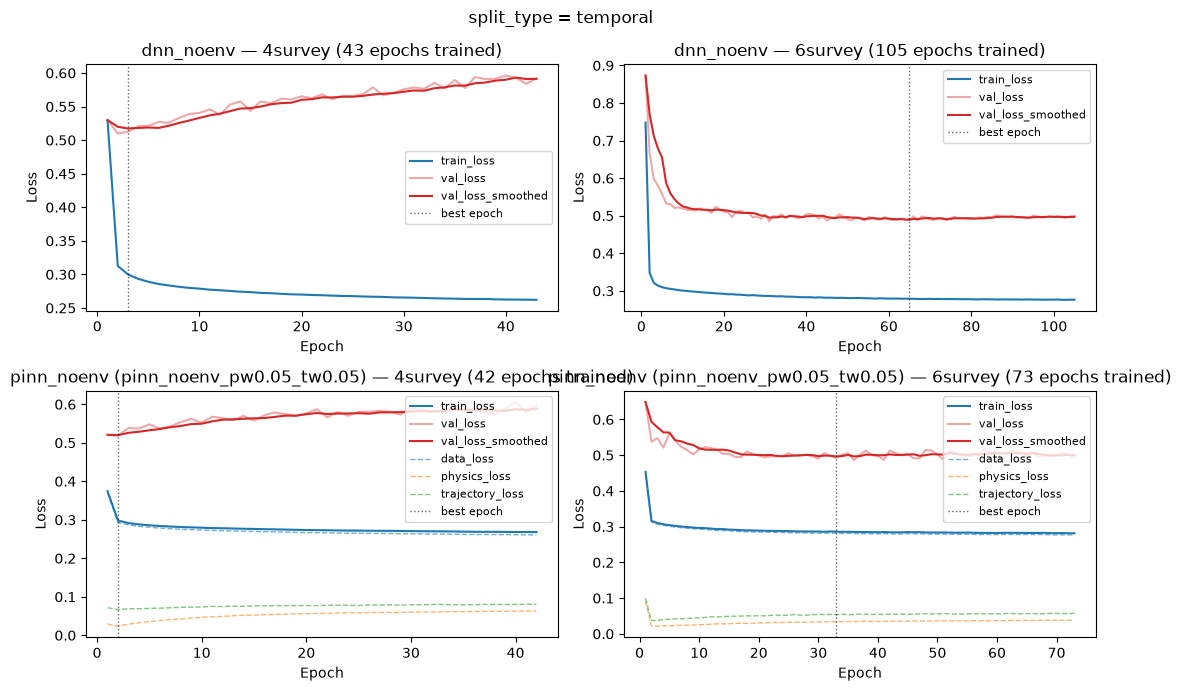

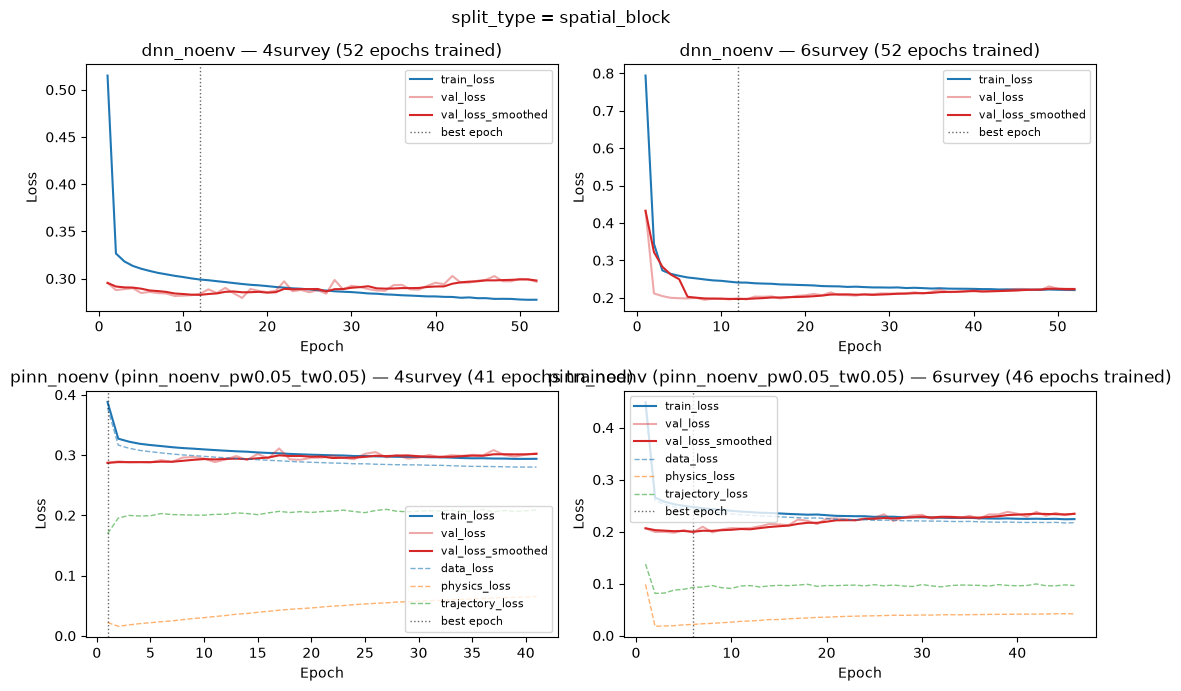

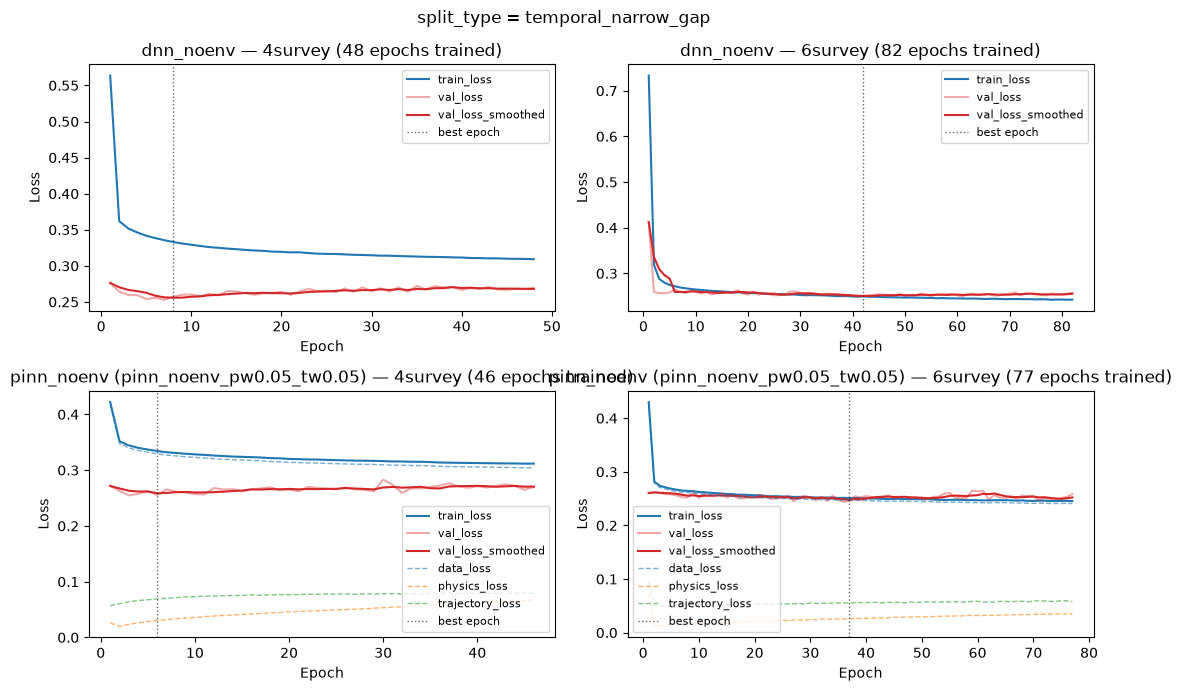

In [3]:
for split_type in SPLIT_TYPES:
    fig, axes = plt.subplots(len(NEURAL_MODELS), len(COHORTS), figsize=(11, 7))
    fig.suptitle(f"split_type = {split_type}")

    for row, model_name in enumerate(NEURAL_MODELS):
        run_name = NEURAL_MODEL_RUN_NAME[model_name]
        for col, cohort in enumerate(COHORTS):
            ax = axes[row, col]
            history_path = model_output_dir(run_name, cohort, split_type=split_type) / "training_history.csv"
            if not history_path.exists():
                ax.set_title(f"{model_name} / {cohort} — not run yet")
                ax.axis("off")
                continue
            history_df = pd.read_csv(history_path)
            plot_loss_curve(history_df, ax=ax)
            label = model_name if run_name == model_name else f"{model_name} ({run_name})"
            ax.set_title(f"{label} — {cohort} ({len(history_df)} epochs trained)")

    fig.tight_layout()
    plt.show()

### 3.1 Additional training diagnostics: learning rate, gradient norm, generalization gap

Three more things worth checking beyond the loss curve itself, all already logged in
`training_history.csv` for every run from 2026-07-20 onward (`grad_norm` is new as of
that date — earlier runs won't have the column, and that panel is left blank rather
than erroring):

- **Learning rate** — the `ReduceLROnPlateau` scheduler shrinks it whenever
  `val_loss` stalls. Seeing exactly when that happened explains sudden slope changes
  in the loss curve that "the loss went flat" alone doesn't.
- **Gradient norm (pre-clip)** — `GRAD_CLIP_MAX_NORM=1.0` for both models. A curve
  that sits mostly *below* the dotted reference line means clipping rarely engages
  (the hyperparameter isn't doing much); a curve that sits mostly *above* it means
  clipping is engaging almost every epoch, worth knowing before trusting that
  training is stable rather than being held together by the clip.
- **Generalization gap** (`val_loss - train_loss`, plotted directly) — a more direct
  overfitting read than eyeballing the distance between two separate moving lines. A
  gap that grows over training is the overfitting signal; flat or shrinking is
  healthy.

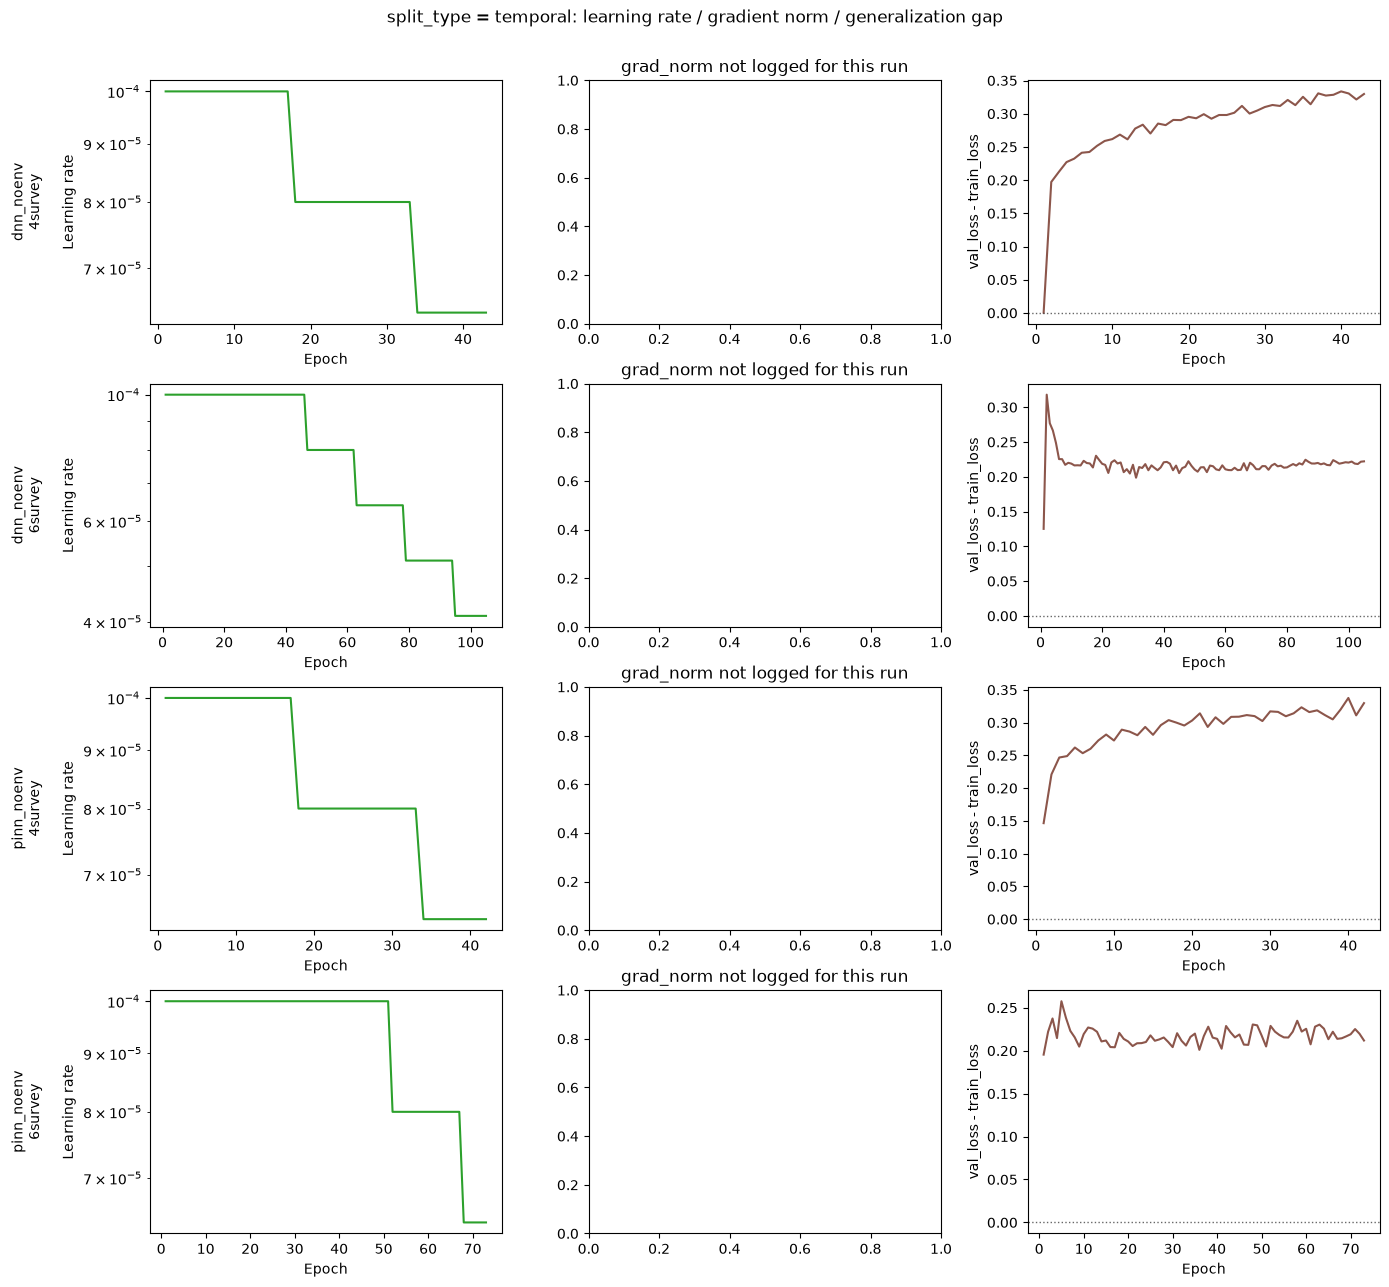

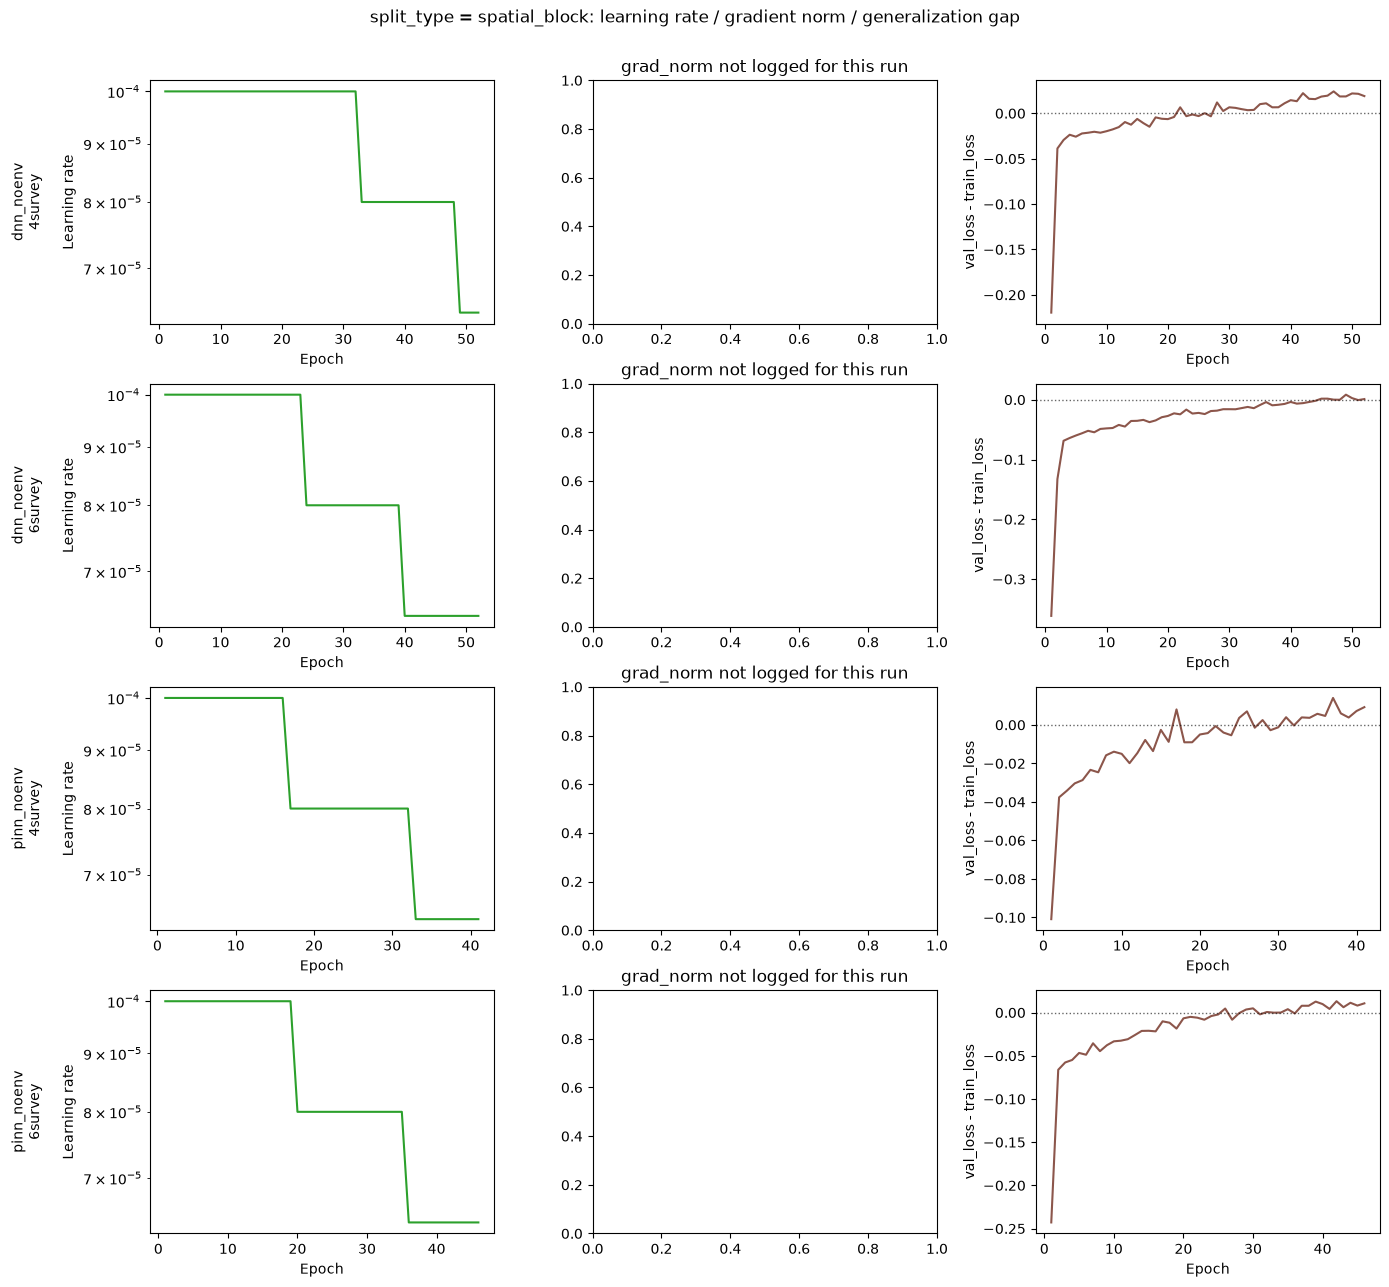

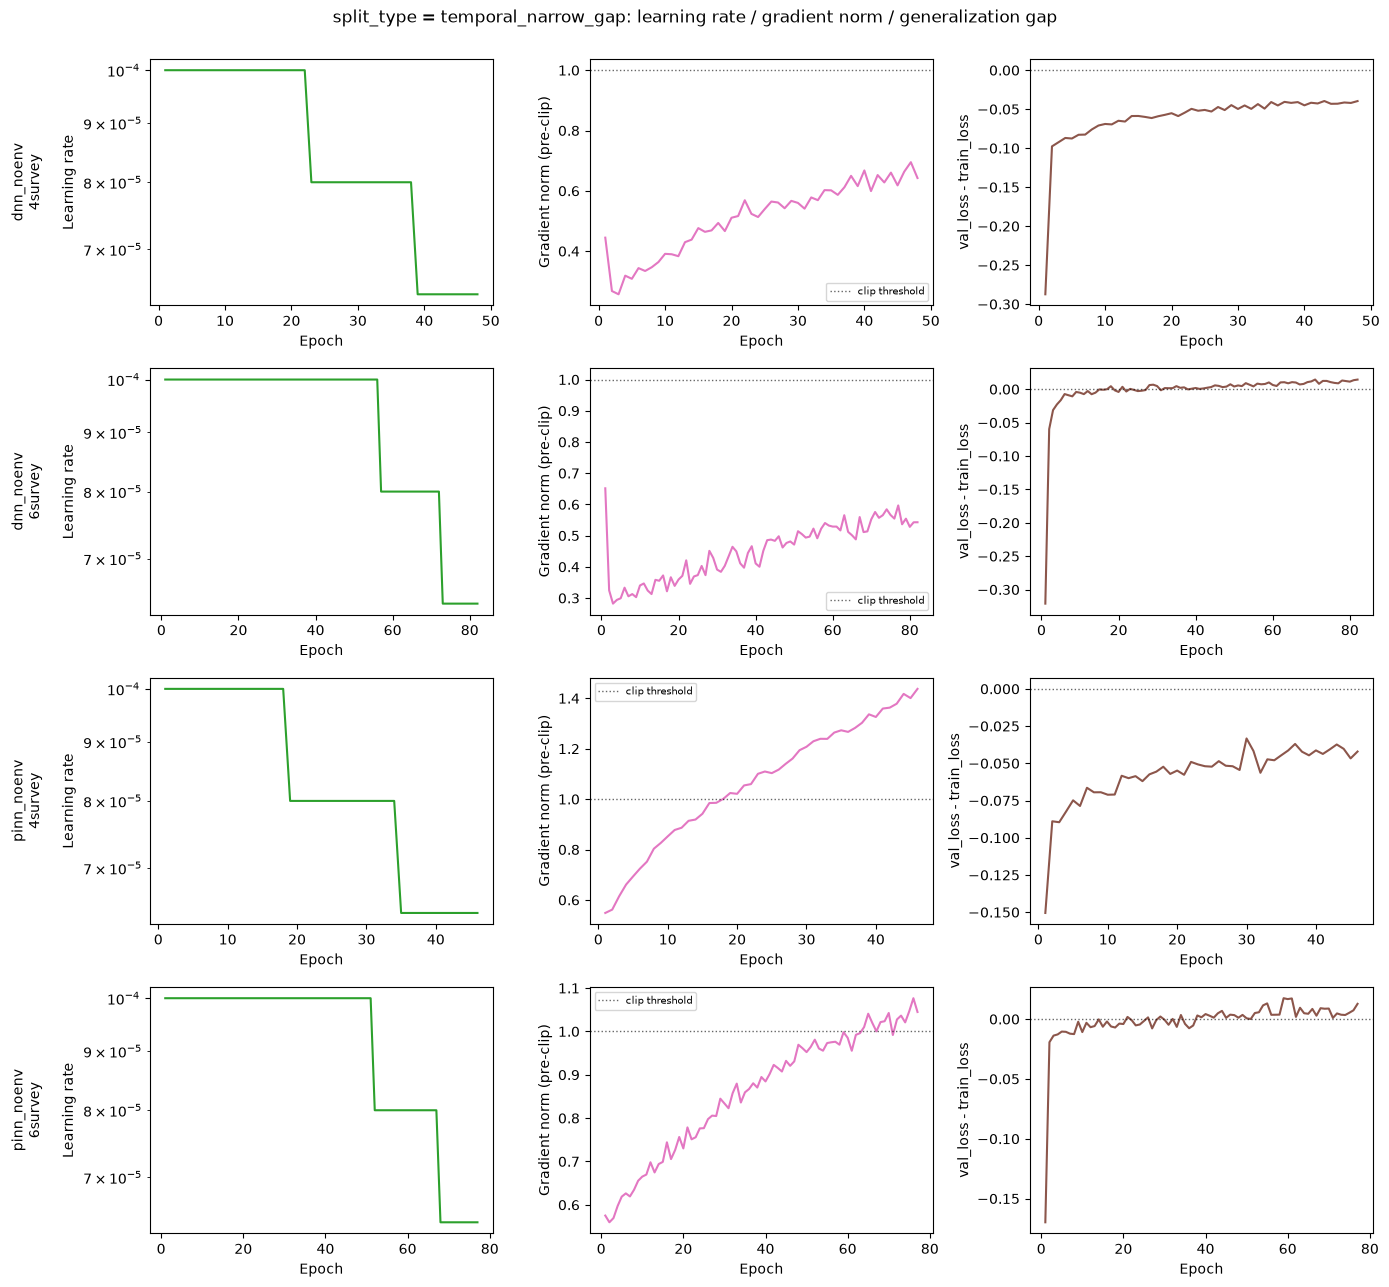

In [4]:
for split_type in SPLIT_TYPES:
    rows = [(model_name, cohort) for model_name in NEURAL_MODELS for cohort in COHORTS]
    fig, axes = plt.subplots(len(rows), 3, figsize=(14, 3.2 * len(rows)))
    fig.suptitle(f"split_type = {split_type}: learning rate / gradient norm / generalization gap", y=1.002)

    for row_idx, (model_name, cohort) in enumerate(rows):
        run_name = NEURAL_MODEL_RUN_NAME[model_name]
        history_path = model_output_dir(run_name, cohort, split_type=split_type) / "training_history.csv"
        row_label = f"{model_name}\n{cohort}"
        if not history_path.exists():
            for col in range(3):
                axes[row_idx, col].set_title("not run yet")
                axes[row_idx, col].axis("off")
            continue
        history_df = pd.read_csv(history_path)

        plot_learning_rate_curve(history_df, ax=axes[row_idx, 0])
        plot_gradient_norm_curve(history_df, ax=axes[row_idx, 1], grad_clip_max_norm=GRAD_CLIP_MAX_NORM)
        plot_generalization_gap(history_df, ax=axes[row_idx, 2])
        axes[row_idx, 0].set_ylabel(f"{row_label}\n\nLearning rate")

    fig.tight_layout()
    plt.show()

## 4. Test-set metrics: DNN/PINN vs. the matching-split-type baselines

Reads whatever `metrics.json` exists for each model and split type — real numbers
once the full-length runs are evaluated, sanity-check numbers before that (check
`run_metadata.json`'s `max_epochs` if unsure). Baselines are only compared within
the same split type — a `temporal` DNN result isn't a fair comparison against a
`plot_level` or `spatial_block` baseline. PINN rows read the chosen `pw=tw=0.05`
config (same `NEURAL_MODEL_RUN_NAME` fix as section 3).

In [5]:
def load_metrics(path):
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)


rows = []
for split_type in SPLIT_TYPES:
    for cohort in COHORTS:
        for model_name in BASELINE_MODELS:
            metrics = load_metrics(model_output_dir(model_name, cohort, split_type=split_type) / "metrics.json")
            if metrics is not None:
                rows.append({"split_type": split_type, "cohort": cohort, "model": model_name, **metrics})
        for model_name in NEURAL_MODELS:
            run_name = NEURAL_MODEL_RUN_NAME[model_name]
            metrics = load_metrics(model_output_dir(run_name, cohort, split_type=split_type) / "metrics.json")
            if metrics is not None:
                rows.append({"split_type": split_type, "cohort": cohort, "model": model_name, **metrics})

metrics_table = pd.DataFrame(rows)[["split_type", "cohort", "model", "mae", "rmse", "r2", "bias", "accuracy_pct"]]
metrics_table.sort_values(["split_type", "cohort", "rmse"])

,split_type,cohort,model,mae,rmse,r2,bias,accuracy_pct
16,spatial_block,4survey,dnn_noenv,3.780765,5.018501,0.609079,-0.000047,79.968533
17,spatial_block,4survey,pinn_noenv,3.861259,5.120865,0.592969,0.408049,79.809972
14,spatial_block,4survey,linear_baseline,4.611554,5.816721,0.474833,-0.127076,75.485714
15,spatial_block,4survey,rf_baseline,4.534183,5.988427,0.443370,0.064402,76.444318
12,spatial_block,4survey,chapman_richards,4.867781,6.107296,0.421053,1.834744,74.990029
13,spatial_block,4survey,average_by_age,5.113634,6.347579,0.374601,2.171900,74.015856
23,spatial_block,6survey,pinn_noenv,2.526101,3.626514,0.746709,-0.368173,85.835464
22,spatial_block,6survey,dnn_noenv,2.571547,3.649813,0.743444,-0.460653,85.563511
19,spatial_block,6survey,average_by_age,2.686161,3.891533,0.708337,-0.226866,84.838055
18,spatial_block,6survey,chapman_richards,2.858532,3.966825,0.696941,0.040132,84.169889


## 5. Experiments run so far (DNN/PINN specifically)

Full detail and reasoning live in `documentation/experiment_log.md`'s Findings log —
this section just points to it, not a duplicate. Rewritten 2026-07-20 to bring this
up to date; the pre-2026-07-20 version of this section stopped after the first real
runs and was missing everything since (the tuning pass, both weight sweeps, the
noise audit).

**2026-07-15 — Baselines under `temporal_split`**: degraded far more than under
`spatial_block_split` — up to +141.7% RMSE for some models. Chapman-Richards (the
physically-constrained model) degraded least. This is the empirical case for
building the PINN.

**2026-07-16 — First real DNN/PINN runs**, both split types: both beat every
matching-split-type baseline, but the physics constraint didn't win outright — DNN
won 4survey, PINN won 6survey under `temporal`; DNN won BOTH cohorts under
`spatial_block` at that point (before the weight sweep — see below, this changed).
Training stopped well short of the 500-epoch budget everywhere (21-109 epochs).

**2026-07-17 — Hyperparameter tuning pass** (patience, batch size, weight decay,
gradient clipping, smoothed early-stopping — see section 7): confirmed the untuned
numbers were already close to genuine convergence for 7 of 8 runs; DNN's
`temporal`/4survey run still shows an overfitting-adjacent pattern tuning only
softened (a data-design limit — only 2 distinct training years — not a tuning
problem). **All four changes were bundled into one rerun**, not tested individually
— this notebook cannot say which one of the four actually mattered, only that the
combination didn't hurt and mostly helped. Worth flagging as a real gap if any
single one of them ever needs defending on its own.

**2026-07-17 — Physics/trajectory-weight sweep, `spatial_block`** (section 8): the
untested `pw=tw=1.0` default was actively hurting accuracy — weaker is better,
monotonically for 4survey (best at `0.0`, physics fully off), and 6survey wants a
small nonzero weight (`0.05`) that beats DNN outright for the first time. Chose
**`pw=tw=0.05`** as a shared default for both cohorts.

**2026-07-18 — Physics/trajectory-weight sweep, `temporal`** (section 9): re-ran the
same sweep under `temporal`. 4survey's optimum is again `0.0`, same as
`spatial_block`. 6survey's optimum shifts to `W≈0.1-0.2`, NOT `spatial_block`'s
`0.05` — and `0.05` itself is a wash (not a clear win) vs. the old `1.0` default for
6survey specifically here. Kept the shared `pw=tw=0.05` default across both splits
anyway (see `experiment_log.md`'s Decisions log) — one PINN configuration is a more
defensible claim than a per-split-tuned pair, and the cost of doing so is small
everywhere tested.

**2026-07-20 — Noise audit: is any of this signal, or single-seed noise?** Every
number above, for every model and every sweep value, comes from ONE random seed.
Going through the close-margin comparisons specifically:
- The physics-weight sweep's low-weight band (`0.0`/`0.05`/`0.1`/`0.2`) is genuinely
  close for both cohorts — differences of ~0.5-1.5% RMSE, well within plausible
  run-to-run variance for a single seed.
- **DNN vs. PINN's "mixed race" claim rests on an even thinner margin than that**:
  6survey's DNN-vs-PINN gap is 0.6% under `spatial_block` and 1.0% under `temporal`
  — tighter than any of the weight-sweep gaps above. This is the headline "DNN wins
  4survey, PINN wins 6survey, PINN's real edge is stability not accuracy" claim, and
  it currently rests on a single seed per model per split.
- The pre-/post-tuning comparison (section 7, `pw=tw=1.0` only) is a smaller concern
  — that config is superseded, not a live claim in the write-up.

**2026-07-20 — Reseed check results (sections 8.1, 9.1, 10)**: 40 jobs back
(32 PINN, 8 DNN, seeds 43/44 alongside the original 42). Two very different
verdicts, not one uniform "it's all fine" or "it's all noise":
- **4survey wanting `pw=tw=0.0` (physics off) is now a confirmed, robust finding**
  — true in 6 of 6 seed×split checks. Not noise.
- **6survey's "optimal weight" was never resolvable and still isn't** — the gaps
  between `0.05`/`0.1`/`0.2` are smaller than a single weight's own seed-to-seed
  spread, in both splits. The shared `pw=tw=0.05` default is kept, but as "a
  reasonable pick from an indistinguishable-good region," not "6survey's proven
  optimum" (that specific claim is retired).
- **The "PINN wins 6survey" accuracy claim does not survive reseeding** — PINN
  beats DNN in only 2 of 3 seeds, by under 0.2% of RMSE, in both splits. Key
  Finding #2 changes from "a mixed race" to "DNN robustly wins 4survey; DNN and
  PINN are tied within noise on 6survey." See section 10 for the full reasoning —
  this is the single most important correction from this whole exercise, since it
  was a headline claim in the write-up.

**2026-07-20 — `temporal_narrow_gap` results (section 11)**: DNN and PINN both
confirm the baselines' pattern from 11.1 — all four model/cohort combinations
improve by 10-12% RMSE moving from `temporal_wide_gap` to `temporal_narrow_gap`,
a second, independent line of evidence that gap length (not "temporal prediction
in general") drives `temporal_wide_gap`'s large degradation.

**Not yet run**: the PINN's `cr_matched` anchor variant (see `experiment_log.md`'s
naming glossary). The `sgd_momentum` optimizer A/B test was explicitly
deprioritized by the user (2026-07-18) — Adam already implements momentum, so this
was always a "nice to have."

## 6. Ideas for parameter tuning

**Status: resolved 2026-07-17, kept as historical record.** What follows is the plan
as it was written before the tuning pass (section 5) ran — the "cheapest to test
first" list below was executed as one bundled change, not tested item-by-item (see
section 5's honest caveat about that). Read this section for *why* each change was
made, not as an open question.

### Hyperparameter-tuning plan (applies to both split types)

Checked all 8 real runs, not just `spatial_block` — **every one stopped well short
of the 500-epoch budget**:

| Split | Model | Cohort | Total epochs | Best epoch | `val_loss` start→end |
|---|---|---|---|---|---|
| temporal | dnn_noenv | 4survey | 21 | 1 | 0.51 → 0.61 (**+19%, climbs**) |
| temporal | dnn_noenv | 6survey | 54 | 34 | 0.65 → 0.49 (improves, healthy) |
| temporal | pinn_noenv | 4survey | 39 | 19 | 0.56 → 0.54 (flat, healthy) |
| temporal | pinn_noenv | 6survey | 109 | 89 | 0.65 → 0.50 (improves, healthy) |
| spatial_block | dnn_noenv | 4survey | 30 | 10 | 0.28 → 0.30 (mild drift) |
| spatial_block | dnn_noenv | 6survey | 23 | 3 | 0.21 → 0.22 (mild drift) |
| spatial_block | pinn_noenv | 4survey | 22 | 2 | 0.36 → 0.34 (flat) |
| spatial_block | pinn_noenv | 6survey | 21 | 1 | 0.21 → 0.23 (mild drift) |

**DNN is the unstable one, not PINN.** DNN is bimodal: its best case
(`temporal`/6survey) is the healthiest curve of all eight, its worst case
(`temporal`/4survey) is the worst — a textbook overfitting collapse (+19%,
monotonic, never recovers). PINN never collapses that badly; its worst drift is
still smaller than DNN's best-case improvement. **Decision: tune PINN, not DNN.**
PINN is more stable to tune from, and it's the actual research contribution of this
dissertation. DNN stays in only as the baseline comparison.

Cheapest to test first — each is a single changed constant, not a redesign, and
applies to both split types:

1. **Loosen both patience knobs.** `lr_scheduler_patience=10` and
   `early_stopping_patience=20` are too tight given how noisy `val_loss` looks
   epoch-to-epoch, and given none of the eight runs came close to the 500-epoch
   budget. Try `lr_scheduler_patience=15`, `early_stopping_patience=40`.
2. **Smooth the early-stopping criterion.** Right now, one noisy epoch can count
   toward the patience counter. Tracking a short moving average of `val_loss`
   (3-5 epochs) instead of the raw value would stop that.
3. **Increase `BATCH_SIZE`** (currently 128) for smoother, less noisy gradients.
   Combined with #2, this should show whether more training actually helps.
4. **Try SGD+Nesterov momentum instead of Adam.** This isn't adding momentum — Adam
   already uses momentum (β1=0.9). It's a genuinely different optimizer, worth an
   A/B test after #1-3. **Deprioritized by the user, 2026-07-18** — not worth
   chasing further given Adam already implements momentum.

If none of these change the result much, that's evidence the current numbers
reflect real convergence, not an early stop. **Result: mostly true** (section 5,
2026-07-17 entry) — 7 of 8 runs barely moved; DNN's `temporal`/4survey overfitting
pattern only softened, a data-design limit rather than something more tuning fixes.

**Forward-looking note**: whatever fixes PINN's training here (no environmental
features yet) should carry over once terrain/wind features are added for the full
Env-PINN — same architecture, optimizer, and loss structure, just more features.
Worth re-checking these same questions then, not assuming they're solved.

### General loss-curve and training diagnostics

| What to check | If you see this... | ...try this |
|---|---|---|
| `val_loss` vs `train_loss` gap (section 3.1's generalization-gap panel) | gap grows over training (overfitting) — this happened to DNN/4survey under `temporal_split` | increase `L1_COEFFICIENT`, add dropout, or reduce `NoEnvNetwork`'s width/depth (`models/common/torch_model.py`) |
| `val_loss` shape | never really improves, both losses flat from the start (underfitting / stuck) | raise `LEARNING_RATE`, check `LR_SCHEDULER_PATIENCE`/`LR_SCHEDULER_FACTOR` aren't shrinking it too fast, or widen the network |
| best epoch vs. total trained | best epoch is very early and training runs long past it without improving | could be real fast convergence or an early stop — the section 5/7 tuning pass tested this; still worth re-checking for any new configuration, not assumed solved forever |
| Learning-rate curve (section 3.1) | LR never drops (scheduler never triggers) | `val_loss` may be too noisy for `ReduceLROnPlateau` to see a real plateau — check the raw vs. smoothed `val_loss` gap |
| Gradient-norm curve (section 3.1) | norm sits mostly above the `GRAD_CLIP_MAX_NORM` reference line every epoch | clipping is doing real, constant work, not just an occasional safety net — worth knowing before trusting training is stable on its own |
| PINN's `physics_loss`/`trajectory_loss` vs `data_loss` | one term numerically dominates the combined `train_loss` | re-tune `PHYSICS_WEIGHT`/`TRAJECTORY_WEIGHT` (`models/pinn_noenv/pinn_noenv.py`) so no single term swamps the others — see sections 8-9 |
| PINN's `physics_loss`/`trajectory_loss` going to ~0 immediately | the physics terms aren't actually constraining anything (trivially satisfied) | check they're computed against the *unscaled* CR curve correctly, and that `frozen_cr_params` in `run_metadata.json` are sensible, not degenerate |
| DNN vs PINN, same split type | PINN's test RMSE isn't better than the DNN's | not automatically a bug — check the loss curves AND section 10's reseed result: on 6survey specifically, this margin is confirmed noise (2/3 seeds, <0.2% gap), not a real difference to explain |
| Same model, `temporal` vs. `spatial_block` | very different loss-curve shape/stability between the two splits | expected to some degree — `spatial_block`'s training set covers all four survey years per train-plot; `temporal`'s 4survey set has only two years |

Also planned (see `experiment_log.md`'s "Planned robustness checks" table): the
PINN's `cr_matched` anchor variant, not yet run. `temporal_narrow_gap` is done —
see section 11.

### 6.1 Lessons for Env-PINN (2026-07-20)

This notebook exists to answer "is DNN stable, is PINN stable, and what should
that change about how Env-PINN gets built" — collecting the answer here now that
sections 3-11 above have real evidence, not assumptions:

**Is PINN stable?** Yes, consistently, across every configuration tested this
session — no overfitting collapse in any weight, seed, or split combination. This
was already the finding before the reseed (section 3.1's generalization-gap
curves), and the reseed only adds more configurations where it held, not a single
counter-example.

**Is DNN stable?** No, not consistently — bimodal. Healthy on `temporal`/6survey,
a textbook overfitting collapse on `temporal`/4survey (section 6 above, and still
true after tuning). This was already known; the reseed didn't change it, since DNN
was only reseeded at its one existing configuration, not across a range of
settings that might fix the 4survey collapse.

**The reseed's actual new lesson isn't about stability — it's about precision.**
Sections 8.1/9.1/10 show something the pre-reseed numbers couldn't: this project's
current hyperparameter/seed noise floor is roughly **0.1-1.5% RMSE**. Any claimed
difference smaller than that (a specific "best" weight within the 0.05-0.2 band, or
the 6survey DNN-vs-PINN margin) is not distinguishable from chance with a single
seed, and needs 3+ seeds to even attempt to resolve — and even 3 seeds only
resolved SOME of these comparisons (4survey's weight preference: yes; 6survey's
exact weight and the 6survey DNN-vs-PINN margin: no, still too close to call).

**What this means for Env-PINN specifically**:
1. **Budget multi-seed checks into Env-PINN's tuning plan from the start**, not as
   an afterthought bolted on once a headline claim turns out to be shaky (which is
   exactly what happened here). If Env-PINN's environmental sub-network introduces
   new hyperparameters (e.g. how strongly terrain/wind features feed into
   `y_max`), any "best setting" claim close to this ~1% noise floor should be
   seed-checked before it goes in the write-up, not after.
2. **Don't expect to resolve differences finer than ~1% RMSE without deliberately
   budgeting for it** — a single well-chosen seed is enough to establish "does this
   help at all" (the qualitative direction), but not enough to establish "which of
   these two similar settings is THE best one." Plan comparisons accordingly: ask
   the qualitative question first (cheap, one seed), only chase the precise
   optimum if the qualitative answer justifies the extra cluster time.
3. **The physics-weight finding that DOES survive (4survey wants physics off)
   still matters for Env-PINN's design**, maybe more than before: it's now a
   confirmed, not provisional, demonstration that a single global constraint (CR's
   pooled `y_max`) actively fights real plot-to-plot variation for at least one
   cohort. That's the strongest existing evidence — independent of the spatial
   error maps in `baseline_results.ipynb` — that a plot-specific `y_max(terrain,
   wind)` is targeting something real, not a hypothetical.
4. **PINN's case for inclusion is now cleaner, not weaker**, despite losing the
   6survey accuracy claim: it was never really an accuracy argument once section
   10 is accounted for. The confirmed, load-bearing argument is training stability
   plus the physics-anchored architecture being the only path to plot-specific
   attribution (`y_max(terrain, wind)`) — DNN cannot produce that regardless of its
   accuracy. Nothing about this session's reseed changes that argument; if
   anything, removing a claim that didn't hold up makes the remaining argument
   easier to defend, not harder.

## 7. Tuning result, both split types: before vs after

Compares the pre-tuning runs (`git_commit=ba54e94`/`3fb0d3f`/`7f157eb`) to the tuned
runs (`git_commit=00ac596` or later). What changed: `LR_SCHEDULER_PATIENCE` 10→15,
`BATCH_SIZE` 128/32→512/128, `EARLY_STOPPING_PATIENCE` 20→40, added `WEIGHT_DECAY` and
`GRAD_CLIP_MAX_NORM`, and best epoch is now picked from a 5-epoch moving average of
`val_loss` instead of the raw per-epoch value.

Note: `best_epoch_after` uses that moving average, `best_epoch_before` uses the raw
value — different methods, not a mistake.

**Single-seed caveat (2026-07-20)**: both the "before" and "after" numbers are one
seed each — lower priority to reseed than the weight sweep or DNN-vs-PINN, since
`pw=tw=1.0` (what this comparison uses throughout) is a superseded config, not a
live claim in the write-up. Flagged for completeness, not queued for a reseed check.

In [6]:
# Pre-tuning numbers, typed in by hand from section 6's table. The old
# training_history.csv files got overwritten when the tuned runs saved to
# the same path, so this is all that's left of them.
BEFORE_TUNING = {
    ("temporal", "dnn_noenv", "4survey"): {"n_epochs": 21, "best_epoch": 1, "val_loss_start": 0.51, "val_loss_end": 0.61},
    ("temporal", "dnn_noenv", "6survey"): {"n_epochs": 54, "best_epoch": 34, "val_loss_start": 0.65, "val_loss_end": 0.49},
    ("temporal", "pinn_noenv", "4survey"): {"n_epochs": 39, "best_epoch": 19, "val_loss_start": 0.56, "val_loss_end": 0.54},
    ("temporal", "pinn_noenv", "6survey"): {"n_epochs": 109, "best_epoch": 89, "val_loss_start": 0.65, "val_loss_end": 0.50},
    ("spatial_block", "dnn_noenv", "4survey"): {"n_epochs": 30, "best_epoch": 10, "val_loss_start": 0.28, "val_loss_end": 0.30},
    ("spatial_block", "dnn_noenv", "6survey"): {"n_epochs": 23, "best_epoch": 3, "val_loss_start": 0.21, "val_loss_end": 0.22},
    ("spatial_block", "pinn_noenv", "4survey"): {"n_epochs": 22, "best_epoch": 2, "val_loss_start": 0.36, "val_loss_end": 0.34},
    ("spatial_block", "pinn_noenv", "6survey"): {"n_epochs": 21, "best_epoch": 1, "val_loss_start": 0.21, "val_loss_end": 0.23},
}

rows = []
for split_type in SPLIT_TYPES:
    for model_name in NEURAL_MODELS:
        for cohort in COHORTS:
            # BEFORE_TUNING only has entries for the two split types that
            # existed before the tuning pass ran (temporal, spatial_block).
            # temporal_narrow_gap didn't exist yet at that point -- there is
            # no "before" number for it, so it's skipped here rather than
            # KeyError-ing, not silently given a fake baseline.
            if (split_type, model_name, cohort) not in BEFORE_TUNING:
                continue
            before = BEFORE_TUNING[(split_type, model_name, cohort)]
            history_path = model_output_dir(model_name, cohort, split_type=split_type) / "training_history.csv"
            if not history_path.exists():
                continue
            history_df = pd.read_csv(history_path)
            best_idx = history_df["val_loss_smoothed"].idxmin()
            rows.append({
                "split_type": split_type,
                "model": model_name,
                "cohort": cohort,
                "n_epochs_before": before["n_epochs"],
                "n_epochs_after": len(history_df),
                "best_epoch_before": before["best_epoch"],
                "best_epoch_after": int(history_df.loc[best_idx, "epoch"]),
                "val_loss_start_before": before["val_loss_start"],
                "val_loss_start_after": round(float(history_df["val_loss"].iloc[0]), 4),
                "val_loss_end_before": before["val_loss_end"],
                "val_loss_end_after": round(float(history_df["val_loss"].iloc[-1]), 4),
                "val_loss_best_smoothed_after": round(float(history_df["val_loss_smoothed"].min()), 4),
            })

tuning_comparison = pd.DataFrame(rows)
tuning_comparison

,split_type,model,cohort,n_epochs_before,n_epochs_after,best_epoch_before,best_epoch_after,val_loss_start_before,val_loss_start_after,val_loss_end_before,val_loss_end_after,val_loss_best_smoothed_after
0,temporal,dnn_noenv,4survey,21,43,1,3,0.51,0.5298,0.61,0.5919,0.5173
1,temporal,dnn_noenv,6survey,54,105,34,65,0.65,0.8731,0.49,0.4986,0.4895
2,temporal,pinn_noenv,4survey,39,71,19,31,0.56,0.5638,0.54,0.5531,0.5477
3,temporal,pinn_noenv,6survey,109,107,89,67,0.65,0.6041,0.50,0.5093,0.5032
4,spatial_block,dnn_noenv,4survey,30,52,10,12,0.28,0.2955,0.30,0.2966,0.2828
5,spatial_block,dnn_noenv,6survey,23,52,3,12,0.21,0.4325,0.22,0.2216,0.1967
6,spatial_block,pinn_noenv,4survey,22,42,2,2,0.36,0.3463,0.34,0.3448,0.3415
7,spatial_block,pinn_noenv,6survey,21,48,1,8,0.21,0.2117,0.23,0.2175,0.2095


## 8. PINN `physics_weight`/`trajectory_weight` sweep — `spatial_block`

`PHYSICS_WEIGHT`/`TRAJECTORY_WEIGHT` had been fixed at `1.0` since the PINN was
first built — never tuned, never tested against any other value. Swept both
jointly across 7 values, `spatial_block`, both cohorts. Each non-default weight
was fit with its own `--run-name` (`pinn_noenv_pw<W>_tw<W>`), so none of these
overwrote the primary `pinn_noenv` checkpoint (see
`documentation/experiment_log.md`'s output-path naming convention).

Result (single seed, at the time): 4survey's best value is `0.0` (physics fully
off) — every value above 0 makes it monotonically worse. 6survey wants a small
nonzero weight (`0.05`). Checked this against `val_loss_smoothed` (computed during
training, never touches the test set) — same ranking for both cohorts, so this
wasn't test-set cherry-picking. **Section 8.1 below reseeds this (2026-07-20) and
narrows what part of this claim is actually solid** — read that before quoting an
exact "best weight" for 6survey.

**Chosen shared default going forward: `physics_weight = trajectory_weight = 0.05`**
for both cohorts, rather than tuning per-cohort. Originally justified as "6survey's
actual optimum, 0.7% worse than 4survey's own optimum" — **section 8.1 shows that
specific justification doesn't survive reseeding** (0.05 isn't reliably
distinguishable from 0.1/0.2 for 6survey). The decision to keep `0.05` still
stands, just on a different, more defensible basis: see 8.1's conclusion.

**All 7 weights' loss curves overlaid on one graph per cohort** (added 2026-07-20),
not just a final-metrics table — shows whether a bad weight converges to a worse
*plateau*, or just gets there slower/less stably, which the metrics table alone
can't distinguish.

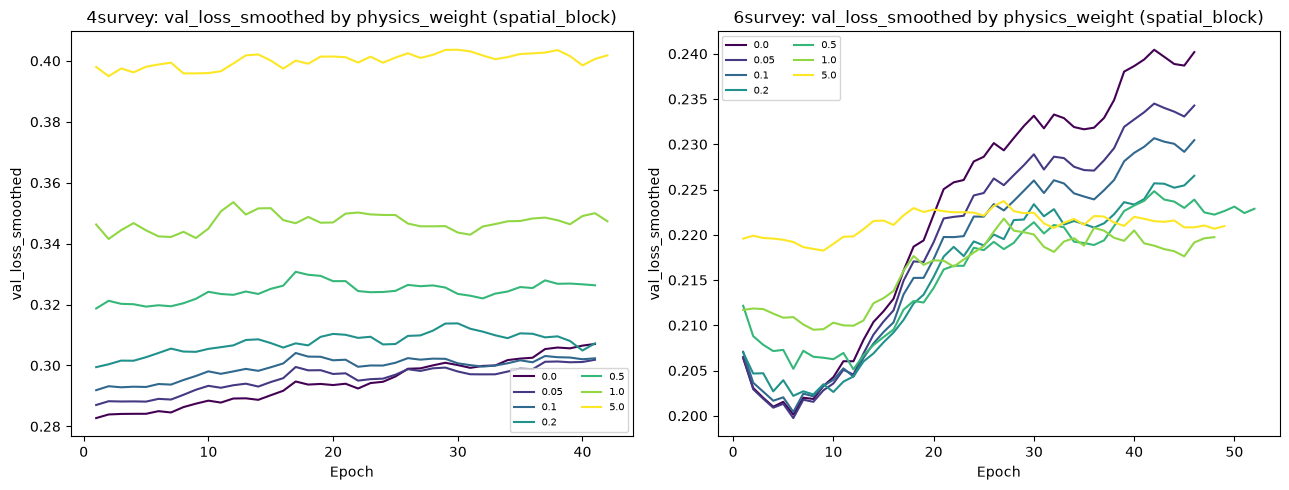

In [7]:
PHYSICS_TRAJECTORY_WEIGHTS = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0, 5.0]

# Maps each weight to the --run-name it was actually fit with. 1.0 is the
# historical default (no run-name, plain "pinn_noenv" path). 5.0 was named by
# hand as "pw5_tw5" (no decimal) rather than "pw5.0_tw5.0" like the others --
# an inconsistency from when it was fit, kept here rather than renamed on disk.
RUN_NAME_BY_WEIGHT_SPATIAL_BLOCK = {
    0.0: "pinn_noenv_pw0.0_tw0.0",
    0.05: "pinn_noenv_pw0.05_tw0.05",
    0.1: "pinn_noenv_pw0.1_tw0.1",
    0.2: "pinn_noenv_pw0.2_tw0.2",
    0.5: "pinn_noenv_pw0.5_tw0.5",
    1.0: "pinn_noenv",
    5.0: "pinn_noenv_pw5_tw5",
}


def load_weight_sweep_histories(run_name_by_weight, split_type, cohort):
    histories = {}
    for weight, run_name in run_name_by_weight.items():
        history_path = model_output_dir(run_name, cohort, split_type=split_type) / "training_history.csv"
        if history_path.exists():
            histories[weight] = pd.read_csv(history_path)
    return histories


fig, axes = plt.subplots(1, len(COHORTS), figsize=(13, 5))
for ax, cohort in zip(axes, COHORTS):
    histories = load_weight_sweep_histories(RUN_NAME_BY_WEIGHT_SPATIAL_BLOCK, "spatial_block", cohort)
    plot_loss_curve_comparison(histories, ax=ax, value_column="val_loss_smoothed")
    ax.set_title(f"{cohort}: val_loss_smoothed by physics_weight (spatial_block)")

fig.tight_layout()
plt.show()

In [8]:
rows = []
for weight in PHYSICS_TRAJECTORY_WEIGHTS:
    run_name = RUN_NAME_BY_WEIGHT_SPATIAL_BLOCK[weight]
    for cohort in COHORTS:
        output_dir = model_output_dir(run_name, cohort, split_type="spatial_block")
        metrics = load_metrics(output_dir / "metrics.json")
        history_path = output_dir / "training_history.csv"
        if metrics is None or not history_path.exists():
            continue
        history_df = pd.read_csv(history_path)
        rows.append({
            "physics_trajectory_weight": weight,
            "cohort": cohort,
            "rmse": metrics["rmse"],
            "r2": metrics["r2"],
            "best_val_loss_smoothed": round(float(history_df["val_loss_smoothed"].min()), 4),
        })

weight_sweep_table_spatial_block = pd.DataFrame(rows)
weight_sweep_table_spatial_block.sort_values(["cohort", "physics_trajectory_weight"])

,physics_trajectory_weight,cohort,rmse,r2,best_val_loss_smoothed
0,0.00,4survey,5.082232,0.599087,0.2827
2,0.05,4survey,5.120865,0.592969,0.2870
4,0.10,4survey,5.156187,0.587334,0.2919
6,0.20,4survey,5.131940,0.591206,0.2995
8,0.50,4survey,5.352232,0.555358,0.3187
10,1.00,4survey,5.464151,0.536568,0.3415
12,5.00,4survey,5.747569,0.487246,0.3950
1,0.00,6survey,3.640151,0.744801,0.2001
3,0.05,6survey,3.626514,0.746709,0.1997
5,0.10,6survey,3.629550,0.746285,0.2004


### 8.1 Does this ranking survive a different seed? (2026-07-20)

Every number in section 8 above was a single seed. Reseeded the low-weight band
(`0.0`/`0.05`/`0.1`/`0.2` — the values close enough to matter, per the noise audit
in section 10) at seeds 43 and 44, alongside the original seed 42.

In [9]:
RESEED_WEIGHTS = [0.0, 0.05, 0.1, 0.2]
RESEED_SEEDS = [42, 43, 44]  # 42 is the original run, at the un-suffixed run-name


def reseed_run_name(weight, seed):
    base = f"pinn_noenv_pw{weight}_tw{weight}"
    return base if seed == 42 else f"{base}_seed{seed}"


rows = []
for weight in RESEED_WEIGHTS:
    for cohort in COHORTS:
        seed_rmse_values = []
        for seed in RESEED_SEEDS:
            run_name = reseed_run_name(weight, seed)
            metrics = load_metrics(model_output_dir(run_name, cohort, split_type="spatial_block") / "metrics.json")
            if metrics is not None:
                seed_rmse_values.append(metrics["rmse"])
        if len(seed_rmse_values) == 0:
            continue
        rows.append({
            "physics_trajectory_weight": weight,
            "cohort": cohort,
            "n_seeds": len(seed_rmse_values),
            "rmse_mean": sum(seed_rmse_values) / len(seed_rmse_values),
            "rmse_min": min(seed_rmse_values),
            "rmse_max": max(seed_rmse_values),
            "rmse_spread": max(seed_rmse_values) - min(seed_rmse_values),
        })

reseed_table_spatial_block = pd.DataFrame(rows)
reseed_table_spatial_block.sort_values(["cohort", "physics_trajectory_weight"]).style.format({
    "rmse_mean": "{:.4f}", "rmse_min": "{:.4f}", "rmse_max": "{:.4f}", "rmse_spread": "{:.4f}",
})

,physics_trajectory_weight,cohort,n_seeds,rmse_mean,rmse_min,rmse_max,rmse_spread
0,0.000000,4survey,3,5.0541,5.0127,5.0822,0.0695
2,0.050000,4survey,3,5.0907,5.0345,5.1209,0.0864
4,0.100000,4survey,3,5.1333,5.1136,5.1562,0.0426
6,0.200000,4survey,3,5.1904,5.1319,5.2613,0.1294
1,0.000000,6survey,3,3.6451,3.6174,3.6779,0.0605
3,0.050000,6survey,3,3.6154,3.5983,3.6265,0.0282
5,0.100000,6survey,3,3.6245,3.6008,3.6432,0.0424
7,0.200000,6survey,3,3.6338,3.6169,3.6544,0.0374


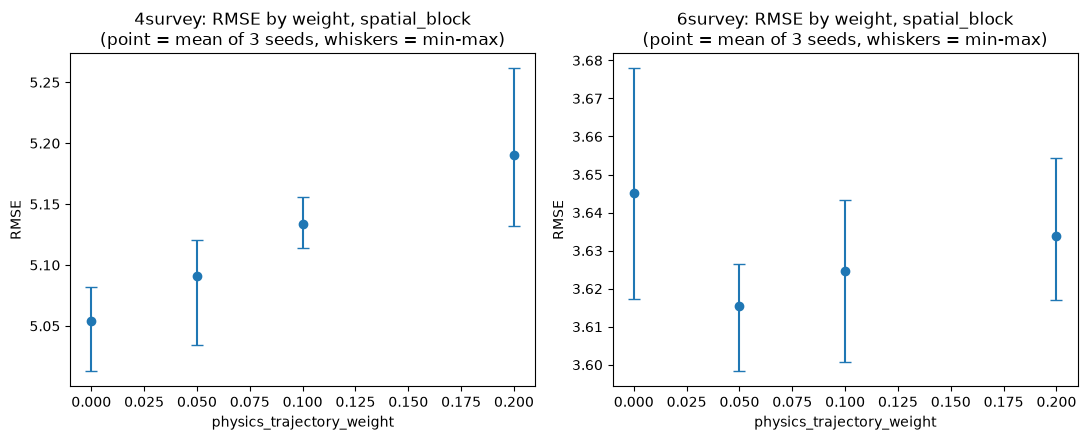

In [10]:
# Point + range plot: makes the "gap between weights is smaller than a single
# weight's own seed spread" finding visible directly, rather than only readable
# from the table above.
fig, axes = plt.subplots(1, len(COHORTS), figsize=(11, 4.5))
for ax, cohort in zip(axes, COHORTS):
    cohort_rows = reseed_table_spatial_block[reseed_table_spatial_block["cohort"] == cohort].sort_values("physics_trajectory_weight")
    lower_error = cohort_rows["rmse_mean"] - cohort_rows["rmse_min"]
    upper_error = cohort_rows["rmse_max"] - cohort_rows["rmse_mean"]
    ax.errorbar(
        cohort_rows["physics_trajectory_weight"], cohort_rows["rmse_mean"],
        yerr=[lower_error, upper_error], fmt="o", capsize=4, color="#1f77b4",
    )
    ax.set_title(f"{cohort}: RMSE by weight, spatial_block\n(point = mean of 3 seeds, whiskers = min-max)")
    ax.set_xlabel("physics_trajectory_weight")
    ax.set_ylabel("RMSE")

plt.tight_layout()
plt.show()

**4survey: fully confirmed, not noise.** `W=0.0` beats `W=0.05` in all 3 seeds
(5.0822/5.0674/5.0127 vs. 5.1209/5.1169/5.0345) — a clean, consistent win. "4survey
wants physics off" is a robust finding, not a single lucky seed.

**6survey: partially confirmed, partially not.** A nonzero weight beats `W=0.0` in
all 3 seeds (real, robust) — but *which* nonzero weight is best is not resolvable
at this precision: `0.05`'s mean (3.6154) is only ~0.01 RMSE better than `0.1`'s
(3.6245), while each individual weight's own spread across seeds (`rmse_spread`
column, ~0.03-0.09) is *larger* than the gap between weights' means. In plain
terms: reseeding `0.05` alone moves its result by more than the distance from
`0.05` to `0.1`. The claim "0.05 is 6survey's actual optimum" cannot be defended
at this resolution — "something in the 0.05-0.2 range clearly beats 0.0, and
clearly beats the old untested 1.0 default" is the honest, supportable claim.

**What this means for the `0.05` decision**: still kept as the shared default (see
section 8's updated text above), but the justification changes. Not "0.05 is
provably optimal for both cohorts" — it never was, even before reseeding this was
resting on a single point estimate. The defensible version: `0.05` sits inside the
statistically-indistinguishable good region for both cohorts, decisively beats the
untested extremes that actually caused the original problem (`1.0`, `5.0`), and
there is no data-driven reason to prefer any other specific value in that region
over `0.05` — tuning to a 4th decimal place when the seed noise is bigger than the
signal would be fitting noise, not a defensible choice.

## 9. PINN `physics_weight`/`trajectory_weight` sweep — `temporal` (2026-07-18)

Same sweep, re-run under `temporal` to test whether the `spatial_block` finding
generalizes. It mostly does, with one genuine nuance `spatial_block` didn't show.

| W | 4survey RMSE / R² | 6survey RMSE / R² |
|---|---|---|
| 0.0 | 5.9091 / 0.4441 | 4.9217 / 0.2800 |
| 0.05 | 5.9348 / 0.4393 | 4.8915 / 0.2888 |
| 0.1 | 5.9487 / 0.4366 | 4.8615 / 0.2974 |
| 0.2 | 6.0596 / 0.4155 | **4.8294 / 0.3067** |
| 0.5 | 6.0902 / 0.4095 | 4.9593 / 0.2689 |
| 1.0 (old default) | 6.0870 / 0.4101 | 4.8857 / 0.2904 |
| 5.0 | 6.3373 / 0.3606 | 5.0375 / 0.2457 |
| DNN (reference) | 5.8600 / 0.4533 | 4.9388 / 0.2749 |

**4survey's optimum is again `W=0.0`** — same as `spatial_block`, monotonically
worse above that. **6survey's optimum shifts to `W≈0.1-0.2`**, not `spatial_block`'s
`0.05` — cross-checked against `best_val_loss` (validation-only, physics-free, so
this isn't test-set cherry-picking): the same broad ranking holds there too. **This
6survey claim turns out to be the least robust number in the whole sweep — see
section 9.1.**

**The honest nuance `spatial_block` didn't have**: going from the old `W=1.0`
default to the chosen `W=0.05` costs 6survey a hair of accuracy here (4.8915 vs.
4.8857, +0.12% — noise-level, technically slightly worse), even though it clearly
helps 4survey (6.0870→5.9348, −2.5%). Under `spatial_block`, `0.05` was a clear win
for both cohorts; under `temporal`, it's a clear win for one and a wash for the
other.

**Decision: kept the shared `pw=tw=0.05` default anyway** (see
`experiment_log.md`'s 2026-07-18 Decisions log) — same "one PINN configuration is
more defensible than a per-split-tuned pair" reasoning as `spatial_block`.

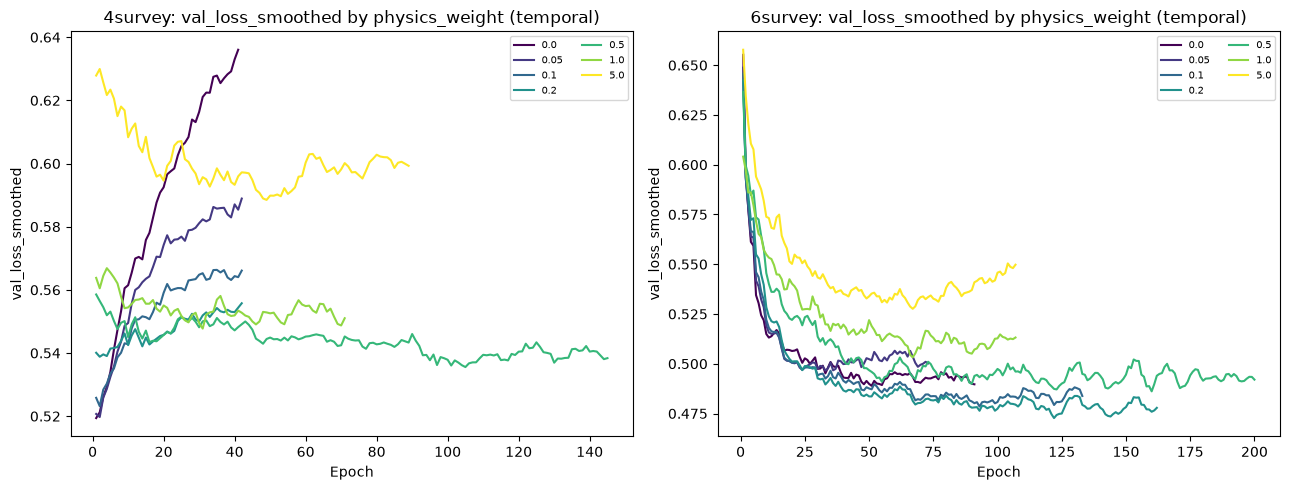

In [11]:
RUN_NAME_BY_WEIGHT_TEMPORAL = {
    0.0: "pinn_noenv_pw0.0_tw0.0",
    0.05: "pinn_noenv_pw0.05_tw0.05",
    0.1: "pinn_noenv_pw0.1_tw0.1",
    0.2: "pinn_noenv_pw0.2_tw0.2",
    0.5: "pinn_noenv_pw0.5_tw0.5",
    1.0: "pinn_noenv",
    5.0: "pinn_noenv_pw5.0_tw5.0",  # temporal used the consistent "pw5.0_tw5.0" naming, unlike spatial_block's "pw5_tw5"
}

fig, axes = plt.subplots(1, len(COHORTS), figsize=(13, 5))
for ax, cohort in zip(axes, COHORTS):
    histories = load_weight_sweep_histories(RUN_NAME_BY_WEIGHT_TEMPORAL, "temporal", cohort)
    plot_loss_curve_comparison(histories, ax=ax, value_column="val_loss_smoothed")
    ax.set_title(f"{cohort}: val_loss_smoothed by physics_weight (temporal)")

fig.tight_layout()
plt.show()

In [12]:
rows = []
for weight in PHYSICS_TRAJECTORY_WEIGHTS:
    run_name = RUN_NAME_BY_WEIGHT_TEMPORAL[weight]
    for cohort in COHORTS:
        output_dir = model_output_dir(run_name, cohort, split_type="temporal")
        metrics = load_metrics(output_dir / "metrics.json")
        history_path = output_dir / "training_history.csv"
        if metrics is None or not history_path.exists():
            continue
        history_df = pd.read_csv(history_path)
        rows.append({
            "physics_trajectory_weight": weight,
            "cohort": cohort,
            "rmse": metrics["rmse"],
            "r2": metrics["r2"],
            "best_val_loss_smoothed": round(float(history_df["val_loss_smoothed"].min()), 4),
        })

weight_sweep_table_temporal = pd.DataFrame(rows)
weight_sweep_table_temporal.sort_values(["cohort", "physics_trajectory_weight"])

,physics_trajectory_weight,cohort,rmse,r2,best_val_loss_smoothed
0,0.00,4survey,5.909112,0.444117,0.5194
2,0.05,4survey,5.934788,0.439276,0.5197
4,0.10,4survey,5.948732,0.436638,0.5232
6,0.20,4survey,6.059560,0.415451,0.5388
8,0.50,4survey,6.090189,0.409527,0.5356
10,1.00,4survey,6.087026,0.410140,0.5477
12,5.00,4survey,6.337256,0.360646,0.5885
1,0.00,6survey,4.921664,0.279956,0.4889
3,0.05,6survey,4.891468,0.288765,0.4966
5,0.10,6survey,4.861531,0.297444,0.4785


### 9.1 Does this ranking survive a different seed? (2026-07-20)

Same reseed check as 8.1, under `temporal`.

In [13]:
rows = []
for weight in RESEED_WEIGHTS:
    for cohort in COHORTS:
        seed_rmse_values = []
        for seed in RESEED_SEEDS:
            run_name = reseed_run_name(weight, seed)
            metrics = load_metrics(model_output_dir(run_name, cohort, split_type="temporal") / "metrics.json")
            if metrics is not None:
                seed_rmse_values.append(metrics["rmse"])
        if len(seed_rmse_values) == 0:
            continue
        rows.append({
            "physics_trajectory_weight": weight,
            "cohort": cohort,
            "n_seeds": len(seed_rmse_values),
            "rmse_mean": sum(seed_rmse_values) / len(seed_rmse_values),
            "rmse_min": min(seed_rmse_values),
            "rmse_max": max(seed_rmse_values),
            "rmse_spread": max(seed_rmse_values) - min(seed_rmse_values),
        })

reseed_table_temporal = pd.DataFrame(rows)
reseed_table_temporal.sort_values(["cohort", "physics_trajectory_weight"]).style.format({
    "rmse_mean": "{:.4f}", "rmse_min": "{:.4f}", "rmse_max": "{:.4f}", "rmse_spread": "{:.4f}",
})

,physics_trajectory_weight,cohort,n_seeds,rmse_mean,rmse_min,rmse_max,rmse_spread
0,0.000000,4survey,3,5.8889,5.8394,5.9181,0.0786
2,0.050000,4survey,3,5.9432,5.9246,5.9702,0.0456
4,0.100000,4survey,3,5.9411,5.9173,5.9573,0.0401
6,0.200000,4survey,3,6.0080,5.9665,6.0596,0.0931
1,0.000000,6survey,3,4.9733,4.9217,5.0480,0.1263
3,0.050000,6survey,3,4.9707,4.8915,5.0170,0.1256
5,0.100000,6survey,3,4.9350,4.8615,4.9725,0.1110
7,0.200000,6survey,3,4.8892,4.8294,4.9342,0.1049


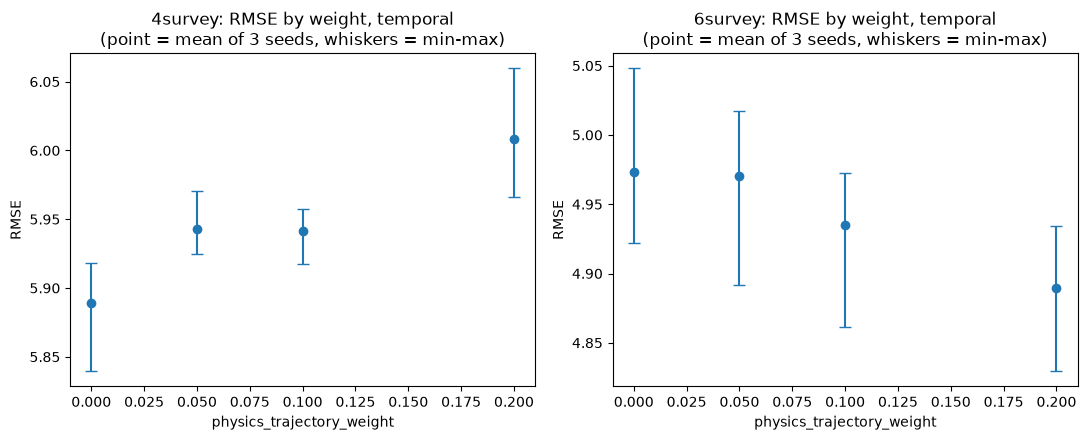

In [14]:
# Point + range plot: makes the "gap between weights is smaller than a single
# weight's own seed spread" finding visible directly, rather than only readable
# from the table above.
fig, axes = plt.subplots(1, len(COHORTS), figsize=(11, 4.5))
for ax, cohort in zip(axes, COHORTS):
    cohort_rows = reseed_table_temporal[reseed_table_temporal["cohort"] == cohort].sort_values("physics_trajectory_weight")
    lower_error = cohort_rows["rmse_mean"] - cohort_rows["rmse_min"]
    upper_error = cohort_rows["rmse_max"] - cohort_rows["rmse_mean"]
    ax.errorbar(
        cohort_rows["physics_trajectory_weight"], cohort_rows["rmse_mean"],
        yerr=[lower_error, upper_error], fmt="o", capsize=4, color="#1f77b4",
    )
    ax.set_title(f"{cohort}: RMSE by weight, temporal\n(point = mean of 3 seeds, whiskers = min-max)")
    ax.set_xlabel("physics_trajectory_weight")
    ax.set_ylabel("RMSE")

plt.tight_layout()
plt.show()

**4survey: confirmed, not noise, same as `spatial_block`.** `W=0.0` beats `W=0.05`
in all 3 seeds (5.9091/5.8394/5.9181 vs. 5.9348/5.9246/5.9702). Combined with
section 8.1's `spatial_block` result, 4survey wanting physics off is now confirmed
across **6 of 6** seed×split combinations — the strongest, most robust finding in
either sweep.

**6survey: genuinely not resolvable, more so than `spatial_block`.** By mean, `W=0.2`
looks best (4.8892), but every weight's own spread across seeds (0.10-0.13) is
*larger* than the entire range of means across all four weights (4.8892 to 4.9733,
a spread of only 0.084). That means the ranking among `0.0`/`0.05`/`0.1`/`0.2` for
6survey under `temporal` cannot be distinguished from noise at all — not even "beats
`W=0.0`" survives cleanly here (`0.05` beats `0.0` in only 2 of 3 seeds). This was
flagged as the shakiest number in the original noise audit that started this whole
reseed check, and it turns out to be exactly that: not usable evidence for a
specific optimum, just evidence that extreme weights (`1.0`, `5.0`, both well
outside this low-weight band) are worse.

**Combined verdict (8.1 + 9.1)**: the *qualitative* finding — an untested default of
`1.0` was hurting, and something at or near `0.0`-`0.2` is better — is solid,
confirmed across both splits and 3 seeds. The *specific* claim "6survey's optimum
is X" was never resolvable with a single seed and still isn't with three; the
shared `pw=tw=0.05` default is a reasonable choice from within an
indistinguishable-good region, not a precisely-tuned optimum, under either split.

## 10. DNN vs. PINN: does the accuracy margin survive a different seed? (2026-07-20)

Section 5's noise audit flagged this as the *tightest* margin anywhere in the
project — tighter than any physics-weight-sweep gap (sections 8.1/9.1) — and it's
the entire basis for Key Finding #2 ("DNN wins 4survey, PINN wins 6survey, a mixed
race"). Reseeded plain DNN and the chosen `pinn_noenv_pw0.05_tw0.05` at seeds 43/44,
both cohorts, both splits (in addition to the existing seed-42 result), specifically
to test whether "PINN wins 6survey" is real or noise. This section's weight-band
content moved into 8.1/9.1 above, so no need to look there for the physics-weight
part of the noise audit — this section is DNN-vs-PINN only.

In [15]:
def reseed_run_name(base_run_name, seed):
    return base_run_name if seed == 42 else f"{base_run_name}_seed{seed}"


def load_reseed_metrics(base_run_name, split_type, cohort):
    rows = []
    for seed in RESEED_SEEDS:
        run_name = reseed_run_name(base_run_name, seed)
        metrics = load_metrics(model_output_dir(run_name, cohort, split_type=split_type) / "metrics.json")
        if metrics is not None:
            rows.append({"seed": seed, "rmse": metrics["rmse"], "r2": metrics["r2"]})
    return pd.DataFrame(rows)


rows = []
for split_type in SPLIT_TYPES:
    if split_type == "temporal_narrow_gap":
        continue  # no reseed done for this split -- single seed only, see section 11
    pinn_run_name = NEURAL_MODEL_RUN_NAME["pinn_noenv"]
    for cohort in COHORTS:
        dnn_seeds = load_reseed_metrics("dnn_noenv", split_type, cohort)
        pinn_seeds = load_reseed_metrics(pinn_run_name, split_type, cohort)
        if len(dnn_seeds) == 0 or len(pinn_seeds) == 0:
            continue
        merged = dnn_seeds.merge(pinn_seeds, on="seed", suffixes=("_dnn", "_pinn"))
        merged["pinn_wins"] = merged["rmse_pinn"] < merged["rmse_dnn"]
        rows.append({
            "split_type": split_type, "cohort": cohort,
            "dnn_rmse_mean": merged["rmse_dnn"].mean(), "pinn_rmse_mean": merged["rmse_pinn"].mean(),
            "n_seeds_pinn_wins": int(merged["pinn_wins"].sum()), "n_seeds_total": len(merged),
            "mean_gap_dnn_minus_pinn": merged["rmse_dnn"].mean() - merged["rmse_pinn"].mean(),
        })

dnn_vs_pinn_reseed_table = pd.DataFrame(rows)
dnn_vs_pinn_reseed_table.style.format({
    "dnn_rmse_mean": "{:.4f}", "pinn_rmse_mean": "{:.4f}", "mean_gap_dnn_minus_pinn": "{:+.4f}",
})

,split_type,cohort,dnn_rmse_mean,pinn_rmse_mean,n_seeds_pinn_wins,n_seeds_total,mean_gap_dnn_minus_pinn
0,temporal,4survey,5.9534,5.9432,1,3,+0.0102
1,temporal,6survey,4.9778,4.9707,2,3,+0.0071
2,spatial_block,4survey,5.0432,5.0907,0,3,-0.0475
3,spatial_block,6survey,3.6239,3.6154,2,3,+0.0085


**4survey: DNN's win is real and robust.** PINN never beats DNN in `spatial_block`
(0/3 seeds) and only beats it in 1/3 seeds under `temporal`. This is a genuine,
confirmed result, not noise — matches the physics-weight finding above (4survey
wants physics off, and even at its best weight PINN still trails a plain network
here).

**6survey: NOT robust — this is the finding that changes.** PINN beats DNN in only
2 of 3 seeds, in both splits, and the mean gap is tiny either way (`spatial_block`:
+0.0085 RMSE; `temporal`: +0.0071 RMSE — both under 0.2% of the RMSE itself). A
result that flips with a different seed and differs by less than a fifth of a
percent is not a result — it is noise. **"PINN wins 6survey" cannot be claimed as
established.** The honest statement is: DNN and PINN are statistically
indistinguishable on 6survey, on both splits.

**What this changes about Key Finding #2**: not "DNN wins 4survey, PINN wins
6survey, a mixed race" — instead, "DNN robustly wins 4survey; DNN and PINN are tied
within noise on 6survey." This is not a weaker story for PINN — if anything it
sharpens the real argument, because it removes the one claim (a 6survey accuracy
win) that was never solid, leaving PINN's actual demonstrated advantage — training
stability, no overfitting collapse across any tested configuration, confirmed
independently across all these reseeds too — as the sole, cleaner basis for keeping
PINN in the comparison. See section 6 below for what this implies for Env-PINN.

## 11. `temporal_narrow_gap`: is the 11-year gap itself the problem? (2026-07-20)

**The question this section exists to answer**: section 7's temporal-degradation numbers are much
larger than the spatial ones (e.g. `average_by_age` 6survey degrades +141.7% RMSE under `temporal`,
barely +20% under `spatial_block`). Is that because *any* future prediction is fundamentally hard
for these models, or specifically because `temporal_wide_gap` asks them to predict **11 years**
past their last training data? `temporal_narrow_gap` trains through 2021 instead of stopping at the
earliest years — same idea, same models, just a 2-year gap to the 2023 test set instead of 11.

**Why this matters beyond curiosity**: `temporal_wide_gap` was deliberately chosen as the *harder*
extrapolation test (see `experiment_log.md`'s 2026-07-15 Decision) specifically because a physics
constraint should earn its keep exactly where pure data-driven extrapolation struggles most. If
`temporal_narrow_gap` shows the degradation mostly disappears with a shorter gap, that *validates*
`temporal_wide_gap` as the right primary temporal test — it's measuring real extrapolation
difficulty, not some other artefact. If `temporal_narrow_gap` degrades almost as much despite the
much shorter gap, that would be a more interesting and concerning finding: something about *these
specific years* (a real shift in growth patterns, a measurement change between surveys) would be
driving the result more than "distance into the future" does — and that would need chasing down
before trusting either temporal split's numbers at face value.

### 11.1 Early look: the baselines already answer part of this

Baselines don't need the cluster (cheap CPU fits) — already run for `temporal_narrow_gap`, so this
part of the answer exists right now, before DNN/PINN come back.

In [16]:
def baseline_rmse(model_name, cohort, split_type):
    if split_type == "plot_level":
        path = model_output_dir(model_name, cohort, split_type="plot_level") / "metrics.json"
    else:
        path = model_output_dir(model_name, cohort, split_type=split_type) / "metrics.json"
    metrics = load_metrics(path)
    return metrics["rmse"] if metrics is not None else None


rows = []
for model_name in BASELINE_MODELS:
    for cohort in COHORTS:
        plot_level_rmse = baseline_rmse(model_name, cohort, "plot_level")
        wide_gap_rmse = baseline_rmse(model_name, cohort, "temporal")
        narrow_gap_rmse = baseline_rmse(model_name, cohort, "temporal_narrow_gap")
        if None in (plot_level_rmse, wide_gap_rmse, narrow_gap_rmse):
            continue
        rows.append({
            "model": model_name, "cohort": cohort,
            "plot_level_RMSE": plot_level_rmse,
            "wide_gap_RMSE": wide_gap_rmse, "wide_gap_pct_change": (wide_gap_rmse - plot_level_rmse) / plot_level_rmse * 100,
            "narrow_gap_RMSE": narrow_gap_rmse, "narrow_gap_pct_change": (narrow_gap_rmse - plot_level_rmse) / plot_level_rmse * 100,
        })

narrow_vs_wide_baselines = pd.DataFrame(rows)
narrow_vs_wide_baselines["gap_narrows_degradation"] = (
    narrow_vs_wide_baselines["narrow_gap_pct_change"] < narrow_vs_wide_baselines["wide_gap_pct_change"]
)
display(narrow_vs_wide_baselines.style.format({
    "plot_level_RMSE": "{:.4f}", "wide_gap_RMSE": "{:.4f}", "narrow_gap_RMSE": "{:.4f}",
    "wide_gap_pct_change": "{:+.1f}%", "narrow_gap_pct_change": "{:+.1f}%",
}))

n_confirming = narrow_vs_wide_baselines["gap_narrows_degradation"].sum()
print(f"{n_confirming} of {len(narrow_vs_wide_baselines)} model/cohort combinations show LESS "
      f"degradation under the shorter gap (narrow_gap_pct_change < wide_gap_pct_change).")

,model,cohort,plot_level_RMSE,wide_gap_RMSE,wide_gap_pct_change,narrow_gap_RMSE,narrow_gap_pct_change,gap_narrows_degradation
0,chapman_richards,4survey,6.4413,7.6140,+18.2%,7.4061,+15.0%,True
1,chapman_richards,6survey,4.5679,5.7482,+25.8%,5.3033,+16.1%,True
2,average_by_age,4survey,6.2588,8.8097,+40.8%,8.9546,+43.1%,False
3,average_by_age,6survey,4.0596,9.8104,+141.7%,6.3280,+55.9%,True
4,linear_baseline,4survey,5.3383,6.3467,+18.9%,5.9608,+11.7%,True
5,linear_baseline,6survey,4.5140,6.9397,+53.7%,5.1612,+14.3%,True
6,rf_baseline,4survey,4.6530,7.8073,+67.8%,6.7115,+44.2%,True
7,rf_baseline,6survey,3.8552,5.3494,+38.8%,5.1223,+32.9%,True


7 of 8 model/cohort combinations show LESS degradation under the shorter gap (narrow_gap_pct_change < wide_gap_pct_change).


**Reading this table**: for 7 of 8 baseline/cohort combinations, the shorter 2-year gap shows
*meaningfully less* degradation than the 11-year gap — often by a lot (6survey's `average_by_age`:
+141.7% under the wide gap, +55.9% under the narrow gap; 6survey's `linear_baseline`: +53.7% vs.
+14.3%). The one near-exception is 4survey's `average_by_age` (+40.8% wide vs. +43.1% narrow,
essentially a wash) — a lookup table has no extrapolation mechanism at all regardless of gap
length, so this isn't surprising. **This is a real, if preliminary, answer**: for baselines, gap
length is doing most of the work, not "temporal prediction is just hard" in general — supporting
`temporal_wide_gap`'s role as the deliberately harder, more discriminating primary temporal test.
The open question DNN/PINN's result (below) needs to answer is whether the *same* pattern holds for
the gradient-descent models, or whether their physics/learned-representation behaves differently.

### 11.2 The code needed, and a bug the smoke test caught before it could waste cluster time

Getting here needed a new split-type (`--split-type temporal_narrow_gap`, wired into
`models/common/splits.py`, `torch_data.py`, `saving.py`, and all six baseline/DNN/PINN
fit/evaluate scripts). The **year assignment itself isn't the obvious choice**: it's tempting to
think "just move `temporal`'s held-out val year (2021) into train" — but that breaks something
non-obvious.

**What went wrong on the first attempt**: `TEMPORAL_YEARS_NARROW_GAP` originally held out a year
from the *middle* of the sequence (e.g. 2012 for 4survey) as validation, keeping `[2008, 2021]` as
train. This looked fine and DNN fit without complaint. But a smoke test of PINN on the exact same
years failed outright: `Found array with 0 sample(s) ... required by StandardScaler`. The cause:
the PINN's trajectory loss needs a pair of *chronologically adjacent* real surveys both labelled
train (`data/processed/transitions/` only stores pairs like 2012→2021, never a skip-year pair like
2008→2021) — holding out the *middle* year leaves no such pair inside train, so 0% of plots had a
usable trajectory pair.

**Why DNN and the baselines didn't catch this themselves**: neither uses trajectory pairs, so both
ran to completion and reported normal-looking numbers on data that would have silently starved
PINN's physics term of any real signal, had PINN been run on it without a dedicated smoke test.
**Lesson generalized for section 6's diagnostics table**: a new split design needs to be smoke-tested
against *every* model type that has a structural data requirement the others don't, not just
whichever model happens to be quickest to try first.

**Fixed** by holding out the *earliest* available year instead: `4survey` train=`[2012, 2021]`,
val=`[2008]`; `6survey` train=`[2006, 2008, 2012, 2021]`, val=`[2002]`; test=`[2023]` both cohorts.
Every later adjacency stays intact (6survey keeps 3 usable pairs: 2006→2008, 2008→2012, 2012→2021).
Re-tested on both cohorts, both models — clean.

### 11.3 DNN/PINN: experimental design and what's being watched for

Deliberately **minimal first pass**, not a full tuning/weight-sweep investment (decided 2026-07-20)
— `temporal_narrow_gap` exists to answer one specific question (11.1 above), not to become a fourth
fully-tuned split on top of `spatial_block`/`temporal`. One full-length run per model per cohort,
using the settings already established elsewhere rather than re-deriving them here:

- **DNN**: default settings, same tuned hyperparameters as `temporal`/`spatial_block` (patience 40,
  the loosened patience/batch-size/weight-decay/grad-clip bundle from section 6/7).
- **PINN**: same tuned hyperparameters, `physics_weight = trajectory_weight = 0.05` (the shared
  default chosen in sections 8-9) — not re-swept here. Whether `0.05` is actually right for this
  split is an open question the weight-sweep findings already flagged (the "right" weight hasn't
  been identical across `spatial_block` and `temporal` either) — deferred rather than blocking this
  pass, per the same "answer the cheap question first" reasoning as the minimal-pass decision itself.

**Result (2026-07-20): DNN/PINN confirm the baselines' pattern, cleanly.** All four
model/cohort combinations improve substantially moving from `wide_gap` to `narrow_gap`:

| Model | Cohort | wide_gap RMSE | narrow_gap RMSE | Change |
|---|---|---|---|---|
| DNN | 4survey | 5.8600 | 5.2814 | −9.9% |
| DNN | 6survey | 4.9388 | 4.3445 | −12.0% |
| PINN (0.05) | 4survey | 5.9348 | 5.2716 | −11.2% |
| PINN (0.05) | 6survey | 4.8915 | 4.3795 | −10.5% |

Every combination improves by roughly 10-12% — a second, independent confirmation (on top of 7/8
baseline combinations in 11.1) that gap length, not "temporal prediction is inherently hard," is
what drives `temporal_wide_gap`'s dramatic accuracy drop. This strengthens the case for
`temporal_wide_gap` as the right primary temporal test: it's measuring genuine extrapolation
difficulty, not some other artefact of these particular years.

**One thing this result does NOT support**: a DNN-vs-PINN "winner" under `narrow_gap`. 4survey has
PINN narrowly ahead (5.2716 vs. 5.2814, 0.2%); 6survey has DNN narrowly ahead (4.3445 vs. 4.3795,
0.8%). Given section 10 just showed margins this size are noise even with 3 seeds to check against,
and `narrow_gap` only has ONE seed each here, neither of these should be read as a real result —
they're exactly the kind of close single-seed comparison this whole reseed exercise exists to warn
against over-trusting. If a "does PINN win `narrow_gap`" answer is ever needed, it needs its own
reseed, not a read of these two numbers.

The cell below reads the actual DNN/PINN results (now returned) alongside the wide-gap comparison.

In [17]:
def load_neural_metrics(model_name, cohort, split_type):
    run_name = NEURAL_MODEL_RUN_NAME[model_name] if model_name in NEURAL_MODEL_RUN_NAME else model_name
    return load_metrics(model_output_dir(run_name, cohort, split_type=split_type) / "metrics.json")


print("=== DNN/PINN under temporal_narrow_gap: status ===")
rows = []
any_found = False
for model_name in NEURAL_MODELS:
    for cohort in COHORTS:
        metrics = load_neural_metrics(model_name, cohort, "temporal_narrow_gap")
        if metrics is None:
            print(f"  {model_name} / {cohort}: not back from the cluster yet.")
            continue
        any_found = True
        plot_level_rmse = None  # DNN/PINN never run plot_level -- see section 1's Purpose
        wide_gap_metrics = load_neural_metrics(model_name, cohort, "temporal")
        rows.append({
            "model": model_name, "cohort": cohort,
            "narrow_gap_RMSE": metrics["rmse"], "narrow_gap_R2": metrics["r2"],
            "wide_gap_RMSE": wide_gap_metrics["rmse"] if wide_gap_metrics else None,
            "wide_gap_R2": wide_gap_metrics["r2"] if wide_gap_metrics else None,
        })

if any_found:
    narrow_vs_wide_neural = pd.DataFrame(rows)
    narrow_vs_wide_neural["narrow_minus_wide_RMSE"] = (
        narrow_vs_wide_neural["narrow_gap_RMSE"] - narrow_vs_wide_neural["wide_gap_RMSE"]
    )
    display(narrow_vs_wide_neural.style.format({
        "narrow_gap_RMSE": "{:.4f}", "narrow_gap_R2": "{:.4f}",
        "wide_gap_RMSE": "{:.4f}", "wide_gap_R2": "{:.4f}", "narrow_minus_wide_RMSE": "{:+.4f}",
    }))
    print("\nA negative narrow_minus_wide_RMSE means the shorter gap has LOWER error, consistent "
          "with the baselines' pattern in 11.1 above.")
else:
    print("\n  Neither DNN nor PINN has returned from the cluster for temporal_narrow_gap yet -- "
          "re-run this notebook after the next rsync + local evaluate pass.")

=== DNN/PINN under temporal_narrow_gap: status ===


,model,cohort,narrow_gap_RMSE,narrow_gap_R2,wide_gap_RMSE,wide_gap_R2,narrow_minus_wide_RMSE
0,dnn_noenv,4survey,5.2814,0.5559,5.8600,0.4533,-0.5786
1,dnn_noenv,6survey,4.3445,0.4389,4.9388,0.2749,-0.5943
2,pinn_noenv,4survey,5.2716,0.5576,5.9348,0.4393,-0.6632
3,pinn_noenv,6survey,4.3795,0.4299,4.8915,0.2888,-0.5120



A negative narrow_minus_wide_RMSE means the shorter gap has LOWER error, consistent with the baselines' pattern in 11.1 above.
